In [1]:
import os
os.chdir(os.path.join(os.getcwd(), '..'))
os.getcwd()

'd:\\learning\\learning\\programing\\portfolio_projects\\1_image'

In [2]:
import optuna
import matplotlib.pyplot as plt
from src.constants.local import OPTUNA_DATABASE_URL


d:\learning\learning\programing\portfolio_projects\1_image\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
study = optuna.load_study(study_name='mri_unet_optuna_search_v2-1: more models less epochs', storage = OPTUNA_DATABASE_URL)

C:\Users\vital\AppData\Local\Temp\ipykernel_12188\464073483.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


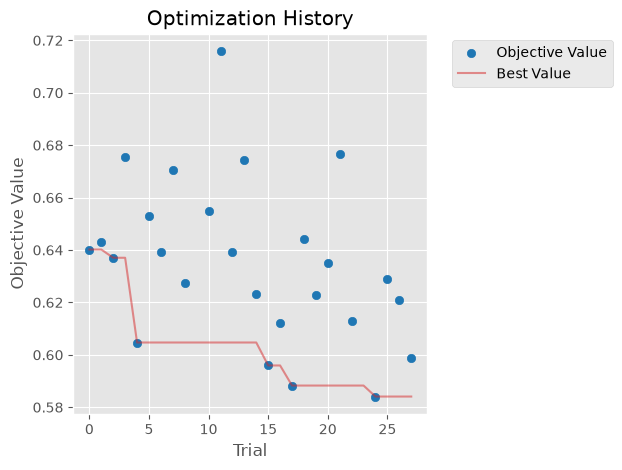

C:\Users\vital\AppData\Local\Temp\ipykernel_12188\464073483.py:5: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


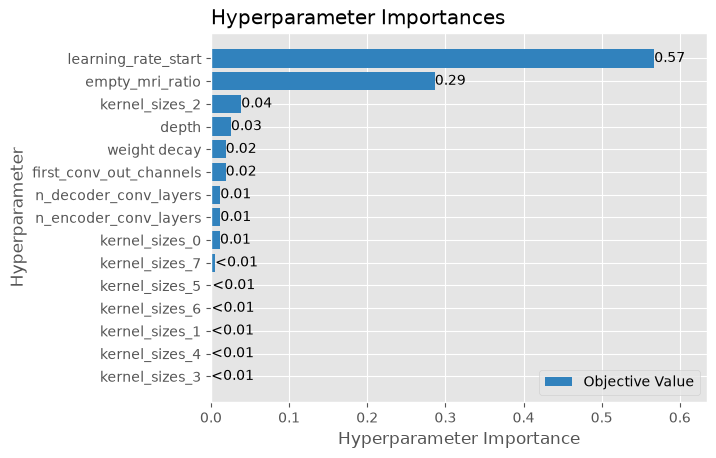

C:\Users\vital\AppData\Local\Temp\ipykernel_12188\464073483.py:8: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  ax = optuna.visualization.matplotlib.plot_parallel_coordinate(study, params = ['learning_rate_start', 'empty_mri_ratio', 'weight decay', 'depth', 'kernel_sizes_0', 'kernel_sizes_7'])


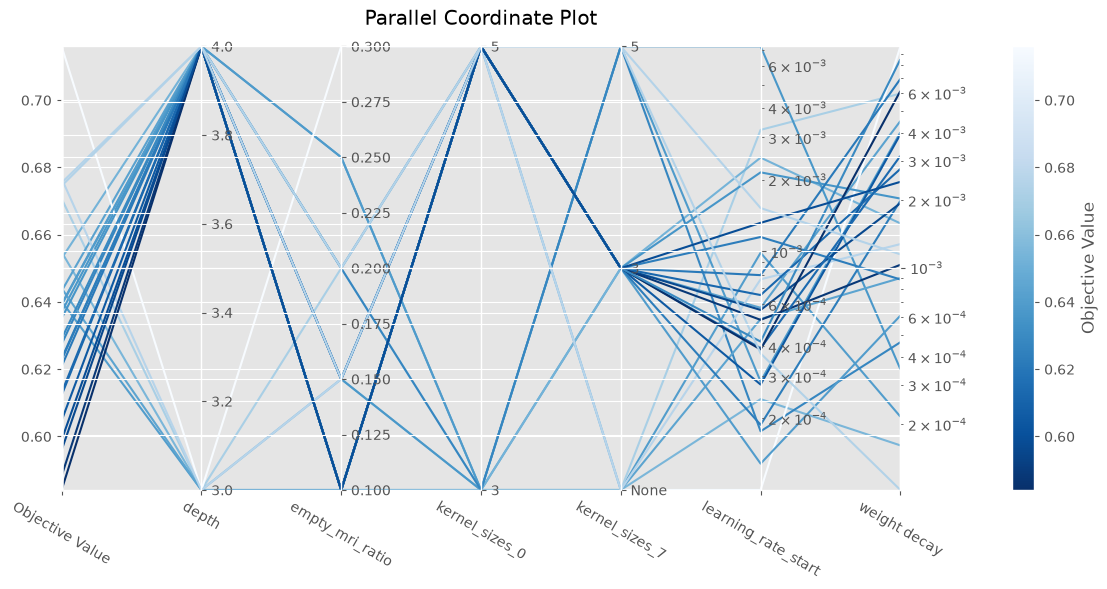

In [4]:
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title('Optimization History')
plt.show()

optuna.visualization.matplotlib.plot_param_importances(study)
plt.show()

ax = optuna.visualization.matplotlib.plot_parallel_coordinate(study, params = ['learning_rate_start', 'empty_mri_ratio', 'weight decay', 'depth', 'kernel_sizes_0', 'kernel_sizes_7'])
fig = ax.figure
fig.set_size_inches(12, 6, forward=True)  
fig.tight_layout()

In [5]:
study.best_params

{'first_conv_out_channels': 64,
 'depth': 4,
 'n_encoder_conv_layers': 2,
 'n_decoder_conv_layers': 2,
 'kernel_sizes_0': 5,
 'kernel_sizes_1': 3,
 'kernel_sizes_2': 3,
 'kernel_sizes_3': 5,
 'kernel_sizes_4': 3,
 'kernel_sizes_5': 5,
 'kernel_sizes_6': 5,
 'kernel_sizes_7': 3,
 'empty_mri_ratio': 0.1,
 'learning_rate_start': 0.0003885771767668683,
 'weight decay': 0.006129038398536625}

C:\Users\vital\AppData\Local\Temp\ipykernel_12188\2391008502.py:1: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  ax = optuna.visualization.matplotlib.plot_parallel_coordinate(study, params = ['n_encoder_conv_layers', 'n_decoder_conv_layers', 'kernel_sizes_0', 'kernel_sizes_2', 'kernel_sizes_7'])


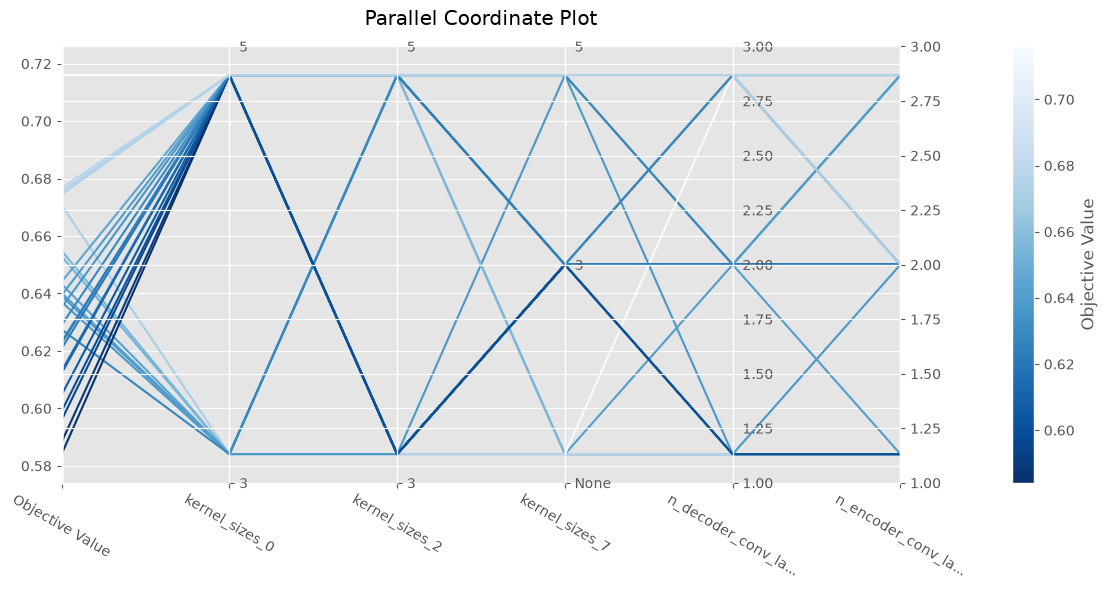

In [9]:
ax = optuna.visualization.matplotlib.plot_parallel_coordinate(study, params = ['n_encoder_conv_layers', 'n_decoder_conv_layers', 'kernel_sizes_0', 'kernel_sizes_2', 'kernel_sizes_7'])
fig = ax.figure
bottom_limit, top_limit = ax.get_ylim()
ax.set_ylim(bottom_limit - 0.01, top_limit + 0.01)
fig.set_size_inches(12, 6, forward=True)  
fig.tight_layout()


In [ ]:
study.trials[0].params[]

{'first_conv_out_channels': 32,
 'depth': 3,
 'n_encoder_conv_layers': 1,
 'n_decoder_conv_layers': 2,
 'kernel_sizes_0': 3,
 'kernel_sizes_1': 5,
 'kernel_sizes_2': 5,
 'kernel_sizes_3': 5,
 'kernel_sizes_4': 5,
 'kernel_sizes_5': 5,
 'empty_mri_ratio': 0.1,
 'learning_rate_start': 0.0009874933714727808,
 'weight decay': 0.0002162374240159287}

In [14]:
df = study.trials_dataframe()

In [31]:
df = df[df['value'].notna()]
df = df = df.sort_values(axis = 0, by = 'value', ignore_index=True )
#df = df.drop('number', axis = 1)

In [34]:
df.head()

,number,value,datetime_start,datetime_complete,duration,params_depth,params_empty_mri_ratio,params_first_conv_out_channels,params_kernel_sizes_0,params_kernel_sizes_1,...,params_kernel_sizes_3,params_kernel_sizes_4,params_kernel_sizes_5,params_kernel_sizes_6,params_kernel_sizes_7,params_learning_rate_start,params_n_decoder_conv_layers,params_n_encoder_conv_layers,params_weight decay,state
0,24,0.584088,2026-09-21 11:00:32.169136,2026-09-21 12:35:55.021573,0 days 01:35:22.852437,4,0.10,64,5,3,...,5,3,5,5.0,3.0,0.000389,2,2,0.006129,COMPLETE
1,17,0.588284,2026-09-20 06:11:58.368461,2026-09-20 07:02:32.386270,0 days 00:50:34.017809,4,0.10,64,5,3,...,5,3,5,3.0,3.0,0.000517,1,1,0.001029,COMPLETE
2,15,0.595946,2026-09-20 04:28:17.838144,2026-09-20 05:28:36.723931,0 days 01:00:18.885787,4,0.10,64,5,3,...,5,3,3,3.0,3.0,0.000569,2,2,0.001937,COMPLETE
3,27,0.598971,2026-09-21 15:54:44.113855,2026-09-21 16:47:02.345383,0 days 00:52:18.231528,4,0.10,64,5,3,...,5,3,5,3.0,3.0,0.001317,1,1,0.002410,COMPLETE
4,4,0.604708,2026-09-19 14:59:44.723923,2026-09-19 15:42:53.707118,0 days 00:43:08.983195,4,0.15,32,5,3,...,5,3,5,5.0,3.0,0.000277,2,2,0.003930,COMPLETE


In [10]:
os.getcwd()

'd:\\learning\\learning\\programing\\portfolio_projects\\1_image'

In [2]:
from src.entity.config_entity import SelectedModelsCreationEntity

d:\learning\learning\programing\portfolio_projects\1_image\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
ent = SelectedModelsCreationEntity(0)

In [11]:
import torch
import lightning.pytorch as pl

In [2]:
from src.components.optuna_model_selection.lightning_modules import MRIModule

In [4]:
model = MRIModule.load_from_checkpoint('mod.ckpt', weights_only = False)

In [20]:
model.hparams

"depth":                   4
"first_conv_out_channels": 64
"inp_channels":            3
"kernel_sizes":            [5, 3, 3, 5, 3, 3, 3, 3]
"learning_rate":           0.0005689453985268673
"n_decoder_conv_layers":   2
"n_encoder_conv_layers":   2
"num_classes":             3
"weight_decay":            0.0019366016985753816

In [5]:
from src.components.optuna_model_selection.dataset import MRIDataset

In [11]:
from src.constants.local import *
from torchvision.transforms import v2
import torch

In [8]:
dataset = MRIDataset(TEST_CSV, 0, v2.Compose([
            v2.Resize(256),
            v2.CenterCrop(256)
            ])
        )

In [58]:
model.eval()
with torch.no_grad():
    inp, mask = dataset[120]

    inp_batch = torch.unsqueeze(inp, 0)
    pred = model(inp_batch)
    pred = torch.sigmoid(pred)
    

In [65]:
out_mask = (pred>0.01)

In [55]:
from src.utils import show_mask_img_from_tensor

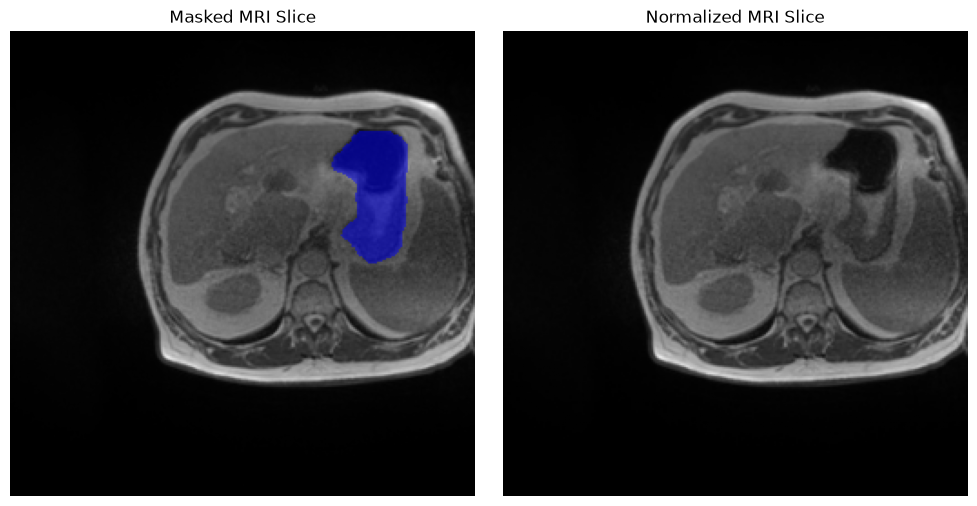

In [63]:
show_mask_img_from_tensor(inp[1], mask, alpha=0.5)

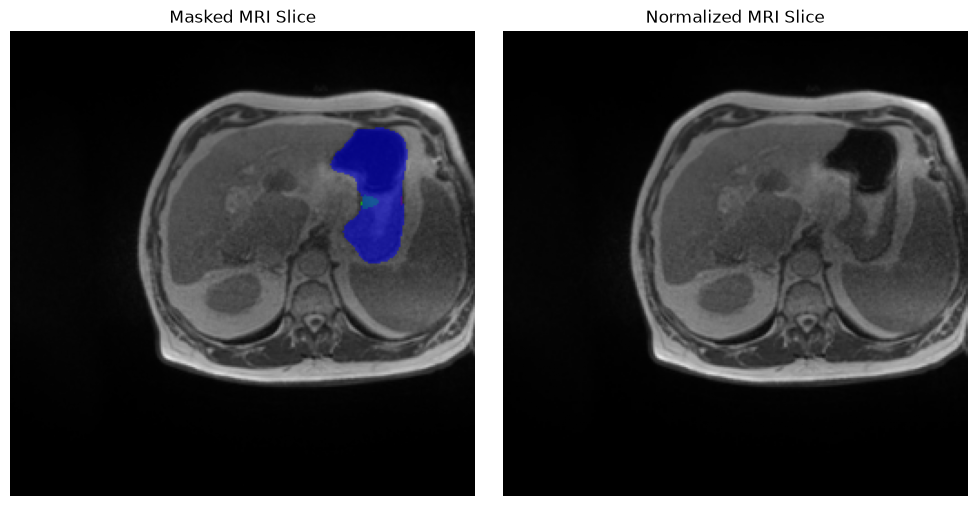

In [66]:
show_mask_img_from_tensor(inp[1], out_mask.squeeze(0), alpha=0.5)

In [23]:
out_mask.shape

torch.Size([1, 3, 256, 256])

In [67]:
import numpy as np

In [72]:
arr = np.zeros([3,5,3])
len(arr.flatten())

45

In [73]:
import pandas as pd
df = pd.read_csv(TRAIN_CSV)


In [75]:
path_col = df.mask_path

In [143]:
def get_weights_for_df(empty_ratio):
     df = pd.read_csv(TRAIN_CSV)
     if empty_ratio >= 1:
          df_new = df
     else:
          df_neg = df[df.empty_slice]
          df_pos = df[~df.empty_slice]
          df_new = pd.concat([df_pos, df_neg.iloc[:int(len(df_pos)*empty_ratio/(1-empty_ratio))]])
     path_col = df_new.mask_path
     ratios = []

     for path in path_col:
          arr = np.load(path)
          leng = np.prod(arr.shape[1:])
          pos = arr.sum(axis = (1,2))
          rat = pos/leng
          ratios.append(rat)

     leng = len(ratios)
     final_ratios = np.sum(ratios, axis = 0)/leng
     weights = (np.negative(final_ratios) + 1) / final_ratios
     return weights

In [80]:
np.load(path_col[1]).shape[1:]

(266, 266)

In [100]:
leng = len(ratios)
final_ratios = np.sum(ratios, axis = 0)/leng

In [101]:
final_ratios

array([0.00710896, 0.00652666, 0.00365945])

In [102]:
df.empty_slice.sum()

np.int64(19929)

In [120]:
df_neg = df[df.empty_slice]
df_pos = df[~df.empty_slice]
df_new = pd.concat([df_pos, df_neg.iloc[:int(len(df_pos)*0.1/(1-0.1))]])


In [121]:
len(df_new)

16950

array([-0.16216, -0.6725 , -1.21768])

In [144]:
get_weights_for_df(0.1)

array([ 66.76699651,  72.81312019, 130.64631503])

In [145]:
get_weights_for_df(0.2)

array([ 75.23487254,  82.03649415, 147.09627935])

In [146]:
get_weights_for_df(0.3)

array([ 86.12556861,  93.89885046, 168.25289069])

In [147]:
get_weights_for_df(1)

array([139.66749294, 152.21774755, 272.26512968])